In [1]:
from system_functions import *
import matplotlib.pyplot as plt

Initialize system with: 
chemical potential (Thomas-Fermi) --> 1.1616532425498978 
size in x --> 33.882458170185174 
size in z --> 374.69979774285855 
size in kx --> 5.910939365360629 
size in kz --> 4.275989106432154 
grid points nx, nz--> 64, 512 
Thomas-Fermi radii Rx, Rz--> 22.588305446790116, 150.94593540709744 
grid spacing dx, dz --> 0.20588104938208654, 0.7318355424665206 
healing length -- > 1.2273848824670373
creating (x, z) <-> (kx, kz) transformation matrix
creating (x, z) <-> (kx, kz) transformation matrix ---> done


In [2]:
psi_gs = get_ground_state(5000, 0.02, 0.1, 0.6)

In [28]:
(1/2 / np.repeat(dv, 2).reshape((2, nx*nz)) * dv[None, :]).reshape((2, nx, nz)).sum(axis=1) / dz / n_atoms

array([[0.00044417, 0.00044417, 0.00044417, ..., 0.00044417, 0.00044417,
        0.00044417],
       [0.00013933, 0.00013933, 0.00013933, ..., 0.00013933, 0.00013933,
        0.00013933]])

In [125]:
noise_k = (np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk), size=(2, nx*nz))
           + 1.0j*np.random.normal(scale=1/np.sqrt(4*n_atoms*dvk), size=(2, nx*nz))).reshape(2*nx*nz)

mask = ((kx_**2 + kz_**2) <= (kx_**2 + kz_**2).max() * 4 / 9).reshape(nx*nz)

noise = ifourier_transform(noise_k.reshape((2, nx*nz)) * mask[None, :], axis=-1).reshape(2*nx*nz)

# noise = (np.random.normal(scale=1/np.sqrt(4*n_atoms*dv), size=(2, nx*nz))
#          + 1.0j*np.random.normal(scale=1/np.sqrt(4*n_atoms*dv), size=(2, nx*nz))).reshape((2*nx*nz))

In [168]:
l = 2
n = 2**10
x = np.linspace(-l/2, l/2, n)
k = 2*np.pi*np.fft.fftfreq(1000, l/n)
f = 1 / (2*np.pi*0.1**2)**(1/4) * np.exp(-0.25 * x**2 / (0.1**2))
g = np.fft.fft(f) * l / n / np.sqrt(2*np.pi)

In [169]:
(np.abs(g)**2).sum() * 2*np.pi / l

np.float64(0.9990234374999999)

In [158]:
(np.abs(f)**2).sum() * l/n

np.float64(0.9990234375)

In [142]:
(f * 2/1000).sum()

np.float64(0.9990000000000001)

In [133]:
2*np.pi*np.fft.fftfreq(2**6, 2 / 2**6)

array([   0.        ,    3.14159265,    6.28318531,    9.42477796,
         12.56637061,   15.70796327,   18.84955592,   21.99114858,
         25.13274123,   28.27433388,   31.41592654,   34.55751919,
         37.69911184,   40.8407045 ,   43.98229715,   47.1238898 ,
         50.26548246,   53.40707511,   56.54866776,   59.69026042,
         62.83185307,   65.97344573,   69.11503838,   72.25663103,
         75.39822369,   78.53981634,   81.68140899,   84.82300165,
         87.9645943 ,   91.10618695,   94.24777961,   97.38937226,
       -100.53096491,  -97.38937226,  -94.24777961,  -91.10618695,
        -87.9645943 ,  -84.82300165,  -81.68140899,  -78.53981634,
        -75.39822369,  -72.25663103,  -69.11503838,  -65.97344573,
        -62.83185307,  -59.69026042,  -56.54866776,  -53.40707511,
        -50.26548246,  -47.1238898 ,  -43.98229715,  -40.8407045 ,
        -37.69911184,  -34.55751919,  -31.41592654,  -28.27433388,
        -25.13274123,  -21.99114858,  -18.84955592,  -15.70796

In [126]:
((np.abs(noise)**2).reshape((2, nx*nz)) * dv[None, :]).sum(axis=-1)

array([0.05817011, 0.05773528])

In [127]:
N = ((np.abs(psi_gs + noise)**2).reshape((2, nx*nz)) * dv[None, :]).sum(axis=-1) - mask.sum()/2/n_atoms

In [128]:
N.sum()

np.float64(1.001096573803608)

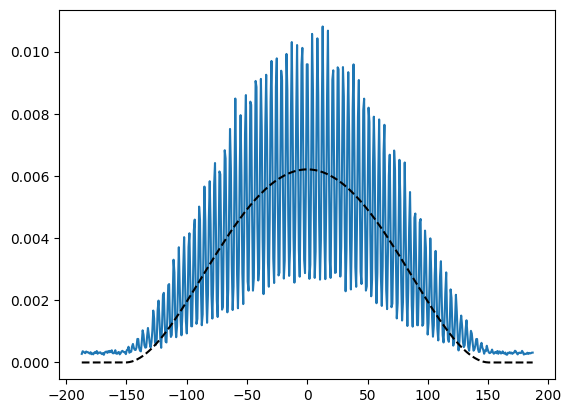

In [112]:
n = ((np.abs(psi_gs + noise)**2).reshape((2, nx*nz))*dv[None, :]/dz).reshape((2, nx, nz)).sum(axis=1) - 0*(nx/2/n_atoms)/dz
ntf = ((mu - ((x_*wx)**2/4 + (z_*wz)**2/4))*(mu > ((x_*wx)**2/4 + (z_*wz)**2/4))).reshape(nx*nz)
ntf = (ntf*dv).reshape((nx, nz)).sum(axis=0)/dz
norm = (ntf*dz).sum()
ntf = ntf/norm
plt.plot(z, n[0] + n[1])
plt.plot(z, ntf, '--k')

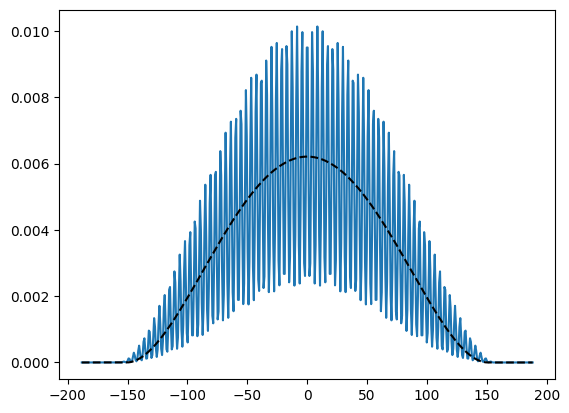

In [13]:
n = ((np.abs(psi_gs)**2).reshape((2, nx*nz))*dv[None, :]/dz).reshape((2, nx, nz)).sum(axis=1)
ntf = ((mu - ((x_*wx)**2/4 + (z_*wz)**2/4))*(mu > ((x_*wx)**2/4 + (z_*wz)**2/4))).reshape(nx*nz)
ntf = (ntf*dv).reshape((nx, nz)).sum(axis=0)/dz
norm = (ntf*dz).sum()
ntf = ntf/norm
plt.plot(z, n[0] + n[1])
plt.plot(z, ntf, '--k')

In [14]:
gn

np.float64(0.7204886914096092)

In [15]:
chi = 0.674328480706184

In [12]:
g*n_atoms*(((psi_gs*psi_gs.conj())**2).reshape((3, nx*nz))*dv[None, :]).real.sum()

np.float64(0.542022695358285)

In [7]:
ntf = ((mu - ((x_*wx)**2/4 + (z_*wz)**2/4))*(mu > ((x_*wx)**2/4 + (z_*wz)**2/4))).reshape(nx*nz)

In [36]:
ntf = ((mu - ((x_*wx)**2/4 + (z_*wz)**2/4))*(mu > ((x_*wx)**2/4 + (z_*wz)**2/4))).reshape(nx*nz)/g
# norm = ((ntf)*dv).sum()
# ntf = ntf / norm

In [25]:
g*(ntf**2*dv).sum()

np.float64(128358.60886861851)

In [46]:
g*n_atoms*(((psi_gs*psi_gs.conj())**2).real.reshape((3, nx*nz))*dv[None, :]).sum()

np.float64(0.6063698403714228)

In [42]:
g*(ntf**2*dv).sum()/n_atoms

np.float64(0.6638013790660267)

In [25]:
101*101/400

25.5025

In [26]:
25.5*40/60

17.0

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from discrete_hankel_transform import dht as dht1
from discrete_hankel_2v import dht as dht2

In [22]:
a = np.random.uniform(size=(1, 2**10))

In [23]:
a1 = dht1(a, axis=-1)
a2 = dht2(a, axis=-1)

In [24]:
%%timeit
a1 = dht1(a, axis=-1)

184 ms ± 269 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [25]:
%%timeit
a2 = dht2(a, axis=-1)

184 ms ± 1.19 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


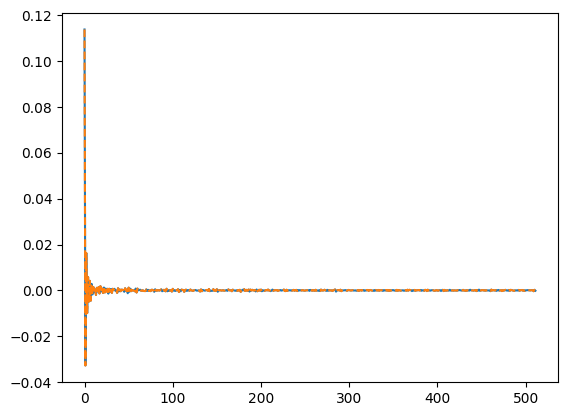

In [15]:
plt.plot(a1[0, :])
plt.plot(a2[0, :])
# plt.ylim(-0.001, 0.001)

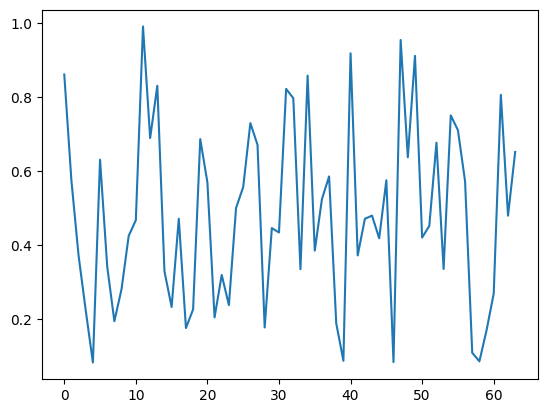

In [4]:
plt.plot(a1[0, :])